In [1]:
pip install pykalman yfinance pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.4/249.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.5/149.5 kB 4.4 MB/s eta 0:00:00


Fetching data for ['EWA', 'EWC']...


/tmp/ipython-input-322997829.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2015-01-01", end="2024-01-01", progress=False)['Close']


Running Kalman Filter (Bayesian Inference)...


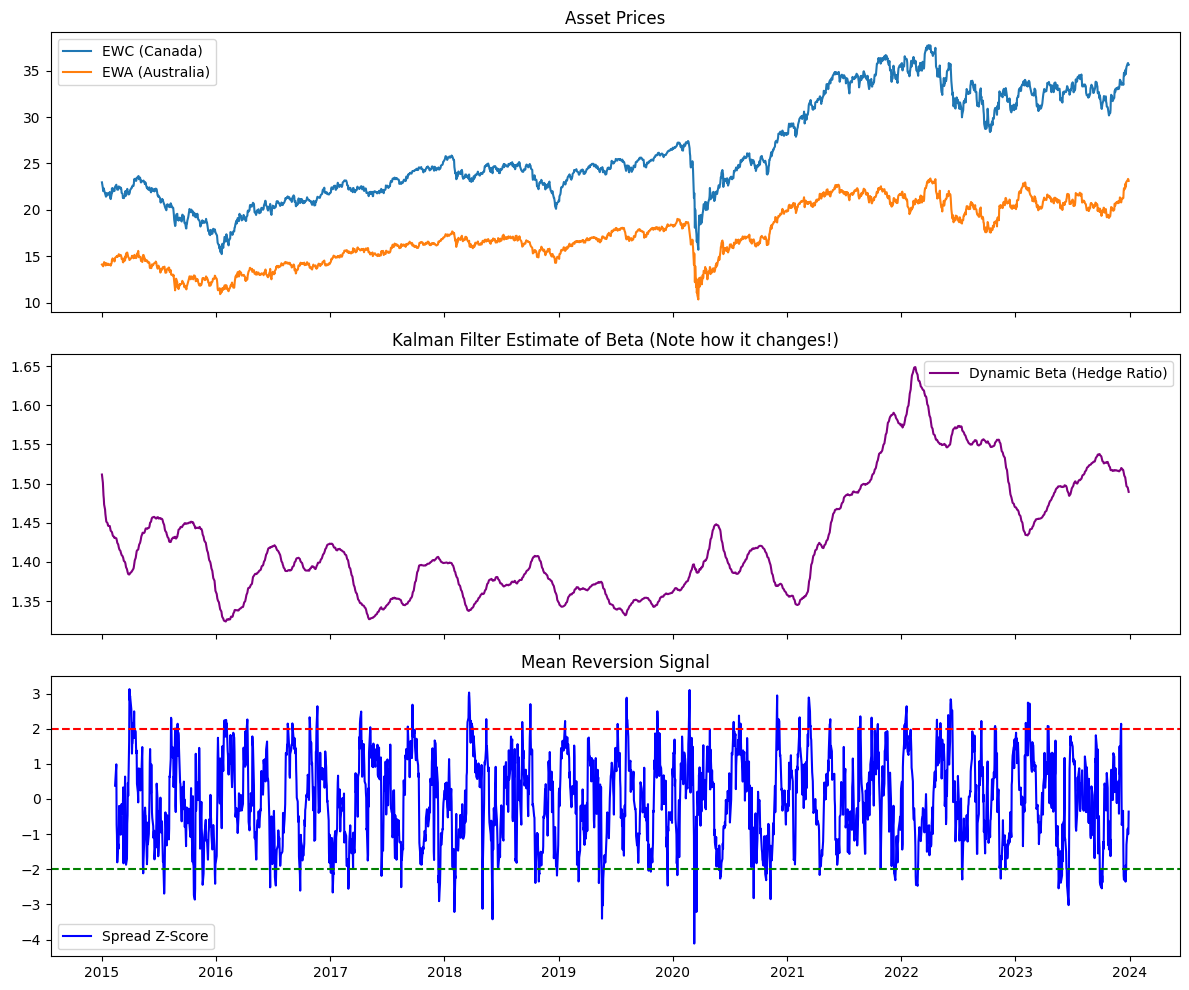

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pykalman import KalmanFilter

# ==========================================
# 1. DATA: Fetch Two Cointegrated Assets
# ==========================================
# EWA (Australia ETF) and EWC (Canada ETF) are a classic commodity pair
tickers = ['EWA', 'EWC']
print(f"Fetching data for {tickers}...")
data = yf.download(tickers, start="2015-01-01", end="2024-01-01", progress=False)['Close']
x = data['EWA']
y = data['EWC']

# ==========================================
# 2. KALMAN FILTER SETUP
# Modeling the "Hidden State" (The Beta and Alpha)
# ==========================================
# We observe Y, and we relate it to X.
# Trans = Transition Matrix (Random Walk Identity)
# Obs = Observation Matrix (The features [1, x])
delta = 1e-5
trans_cov = delta / (1 - delta) * np.eye(2)

kf = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=2,
    initial_state_mean=np.zeros(2),
    initial_state_covariance=np.ones((2, 2)),
    transition_matrices=np.eye(2),
    observation_matrices=np.expand_dims(np.vstack([[data['EWA'], np.ones(len(data['EWA']))]]).T, axis=1),
    observation_covariance=1.0,
    transition_covariance=trans_cov
)

# ==========================================
# 3. RUN THE FILTER (The "Learning")
# ==========================================
print("Running Kalman Filter (Bayesian Inference)...")
state_means, state_covs = kf.filter(data['EWC'].values)

# Extract the Dynamic Parameters
# Slope = Beta (The Hedge Ratio)
# Intercept = Alpha
dynamic_slope = state_means[:, 0]
dynamic_intercept = state_means[:, 1]

# ==========================================
# 4. GENERATE THE SPREAD (The Signal)
# ==========================================
# Prediction error: Actual Y - Predicted Y
# This "Spread" is mean-reverting by definition of the model
spread = data['EWC'] - (data['EWA'] * dynamic_slope + dynamic_intercept)

# Calculate Z-Score of the spread for trading signals
# (Standardizing it so we know when it's 2 deviations away)
z_score = (spread - spread.rolling(window=30).mean()) / spread.rolling(window=30).std()

# ==========================================
# 5. VISUALIZATION
# ==========================================
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot 1: The Prices
ax[0].plot(data.index, data['EWC'], label='EWC (Canada)')
ax[0].plot(data.index, data['EWA'], label='EWA (Australia)')
ax[0].set_title("Asset Prices")
ax[0].legend()

# Plot 2: The Dynamic Beta (The Ph.D. Part)
ax[1].plot(data.index, dynamic_slope, color='purple', label='Dynamic Beta (Hedge Ratio)')
ax[1].set_title("Kalman Filter Estimate of Beta (Note how it changes!)")
ax[1].legend()

# Plot 3: The Trading Signal (Z-Score)
ax[2].plot(data.index, z_score, color='blue', label='Spread Z-Score')
ax[2].axhline(2.0, color='red', linestyle='--')
ax[2].axhline(-2.0, color='green', linestyle='--')
ax[2].set_title("Mean Reversion Signal")
ax[2].legend()

plt.tight_layout()
plt.show()

Running Event-Driven Backtest...


/tmp/ipython-input-43012479.py:107: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download('SPY', start="2015-01-01", end="2024-01-01", progress=False)['Close']


--- KALMAN FILTER STRATEGY RESULTS ---
Total Return:    14.68%
Sharpe Ratio:    0.39
Max Drawdown:    -6.25%


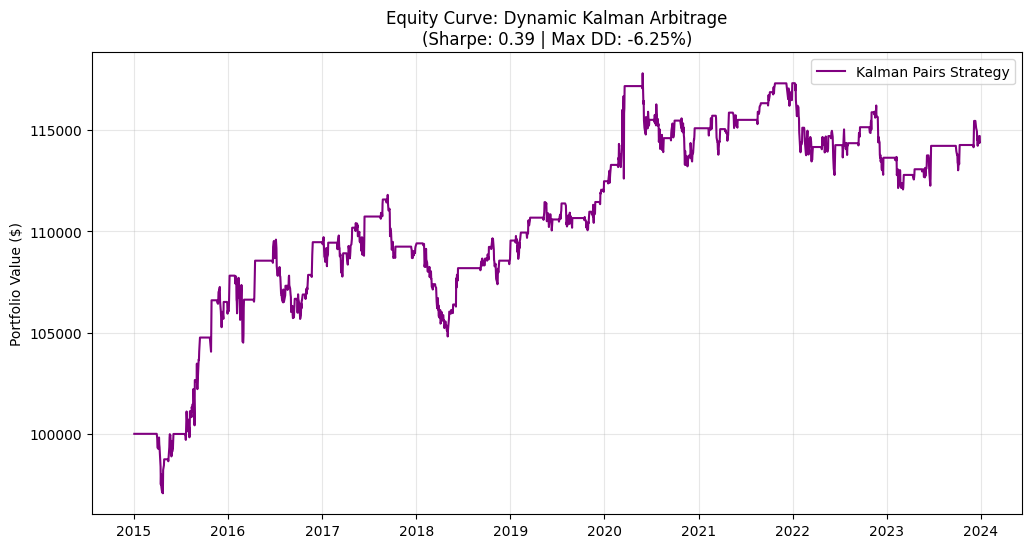

In [3]:
# ==========================================
# 1. SETUP BACKTEST DATAFRAME
# ==========================================
# Combine all necessary data into one clean dataframe
backtest_df = pd.DataFrame(index=data.index)
backtest_df['price_y'] = data['EWC'] # Long Leg Candidate
backtest_df['price_x'] = data['EWA'] # Short Leg Candidate
backtest_df['hedge_ratio'] = dynamic_slope # The Kalman Beta
backtest_df['z_score'] = z_score

# Strategy Parameters
entry_threshold = 2.0  # Enter when spread is 2 std devs away
exit_threshold = 0.0   # Exit when spread reverts to mean
initial_capital = 100000
cost_per_trade = 0.0010 # 10 bps (0.10%)

# ==========================================
# 2. THE BACKTEST LOOP (Event-Driven)
# We loop to handle state management (Holding positions)
# ==========================================
positions = [0] * len(backtest_df) # 1 = Long Spread, -1 = Short Spread
cash = [initial_capital] * len(backtest_df)
portfolio_value = [initial_capital] * len(backtest_df)

current_pos = 0 # 0=Cash, 1=Long, -1=Short
qty_y = 0
qty_x = 0

print("Running Event-Driven Backtest...")

for t in range(1, len(backtest_df)):
    # Get today's data
    today = backtest_df.iloc[t]
    prev_close_y = backtest_df.iloc[t-1]['price_y']
    prev_close_x = backtest_df.iloc[t-1]['price_x']

    # 1. MARK TO MARKET (Update Portfolio Value based on price moves)
    equity_y = qty_y * today['price_y']
    equity_x = qty_x * today['price_x']
    current_equity = cash[t-1] + equity_y + equity_x

    # 2. GENERATE SIGNALS (Check Z-Score)
    # Logic: If Z > 2, Spread is expensive -> Short Spread (Short Y, Long X)
    #        If Z < -2, Spread is cheap -> Long Spread (Buy Y, Short X)

    # EXIT CONDITIONS
    if current_pos == 1 and today['z_score'] > -exit_threshold:
        # Close Long Position
        cash[t] = current_equity - (abs(equity_y + equity_x) * cost_per_trade)
        qty_y = 0
        qty_x = 0
        current_pos = 0

    elif current_pos == -1 and today['z_score'] < exit_threshold:
        # Close Short Position
        cash[t] = current_equity - (abs(equity_y + equity_x) * cost_per_trade)
        qty_y = 0
        qty_x = 0
        current_pos = 0

    # ENTRY CONDITIONS
    elif current_pos == 0:
        # Long The Spread (Buy Y, Sell X)
        if today['z_score'] < -entry_threshold:
            # Allocate $50k to Y, and hedge with X
            target_y_equity = current_equity / 2
            qty_y = target_y_equity / today['price_y']
            # Hedge Ratio determines X quantity: Qty_X = - (Qty_Y * Beta)
            qty_x = - (qty_y * today['hedge_ratio'])

            # Deduct costs
            transaction_amt = (qty_y * today['price_y']) + abs(qty_x * today['price_x'])
            cash[t] = current_equity - (transaction_amt * cost_per_trade) - (qty_y * today['price_y']) - (qty_x * today['price_x'])
            current_pos = 1

        # Short The Spread (Sell Y, Buy X)
        elif today['z_score'] > entry_threshold:
            target_y_equity = current_equity / 2
            qty_y = - (target_y_equity / today['price_y'])
            qty_x = - (qty_y * today['hedge_ratio']) # Negative times Negative = Positive quantity

            transaction_amt = abs(qty_y * today['price_y']) + (qty_x * today['price_x'])
            cash[t] = current_equity - (transaction_amt * cost_per_trade) - (qty_y * today['price_y']) - (qty_x * today['price_x'])
            current_pos = -1

        else:
            # No Trade, Carry forward cash
            cash[t] = current_equity

    else:
        # HOLD POSITION (Carry forward cash, update equity in next loop)
        cash[t] = cash[t-1]

    portfolio_value[t] = cash[t] + (qty_y * today['price_y']) + (qty_x * today['price_x'])
    positions[t] = current_pos

backtest_df['portfolio_value'] = portfolio_value
backtest_df['position'] = positions

# ==========================================
# 3. PERFORMANCE METRICS
# ==========================================
# Calculate returns
backtest_df['strategy_return'] = backtest_df['portfolio_value'].pct_change()

# Benchmarks (SPY and Buy-and-Hold EWC)
spy = yf.download('SPY', start="2015-01-01", end="2024-01-01", progress=False)['Close']
if isinstance(spy.columns, pd.MultiIndex): spy = spy.iloc[:, 0]
spy_returns = spy.pct_change()

# Sharpe Ratio (Annualized)
daily_mean = backtest_df['strategy_return'].mean()
daily_std = backtest_df['strategy_return'].std()
sharpe = (daily_mean / daily_std) * (252**0.5)

# Max Drawdown
cum_ret = (1 + backtest_df['strategy_return']).cumprod()
running_max = cum_ret.cummax()
drawdown = (cum_ret - running_max) / running_max
max_dd = drawdown.min()

print(f"--- KALMAN FILTER STRATEGY RESULTS ---")
print(f"Total Return:    {((portfolio_value[-1]/initial_capital)-1)*100:.2f}%")
print(f"Sharpe Ratio:    {sharpe:.2f}")
print(f"Max Drawdown:    {max_dd*100:.2f}%")

# ==========================================
# 4. VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(backtest_df.index, backtest_df['portfolio_value'], label='Kalman Pairs Strategy', color='purple')
plt.title(f"Equity Curve: Dynamic Kalman Arbitrage\n(Sharpe: {sharpe:.2f} | Max DD: {max_dd*100:.2f}%)")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()